In [212]:
import sys
import os
import glob
sys.path.append("/home/tg8455/srths/downloaded_code")
from BBSims import noise_calc
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from itertools import combinations_with_replacement as cwr
from copy import deepcopy
import astropy.units as u

from dataclasses import dataclass, field
from typing import List, Dict, Optional,Callable

I will be recreating the workflow of the previous notebook (switching bc the covariance workflow is different)

### 1. Theory

Note: This workflow is built for one iso parameter, one Fisher only. Please be careful to set the values of your desired parameters at the beginning; you should use the same array for both the theory power spectrum and the fiducial values for the Fisher (think about why: your covariance contains the cosmic variance term for a certain power spectrum, but then your -- shortcut-- dC will be constructed from an entirely different ps)

In [270]:
sys.path.append("/home/tg8455/srths/code_bases/cosmocast_makelik")
from iso_theory import compute_cls, _apply_cuts, _interp_to, make_cross_noise, knox_auto_cov, knox_cross_cov

In [214]:
ISO_TYPE_NOW = 'cdi'
CORR_TYPE_NOW = 'ucor'

LMAX = 5000

cmb_theo_dict = {}
if CORR_TYPE_NOW == 'ucor':
    cmb_theo_dict = compute_cls(LMAX, iso_mode = ISO_TYPE_NOW)

### 2. The Fake Likelihood

note:  I will not be importing the likelihood code from makelik, but rather writing one from scratch for the senior thesis workflow 

The new version of the likelihood is, for better or for worse, dependent on Planck Lite. The code works differently, because you will have **exactly one data vector** from which you very easily create a Knox covariance: 
- take in your req_spec and your setup so it knows what noise spectra you want (it is, in theory, still flexible to simulated Planck data, if that strikes your fancy)
- you should have your nz_dict from before (which is a data product that is UNIVERSAL; I do not need to generate it every time, I can just store it into a .yaml or sum shit, but will figure it out a bit later). From this nz_dict you build noise power spectra, which you then combine into ONE, using inverse variance ($N_{\ell} = \frac{1}{\sum_{exp}1/N^i_{\ell}}$). You can work on the ell_grid dictated by your nz_dict. You do this for all the experiments requested in your experimental setup (I will leave fake PK out for now, fly high sweet angel).
- the good thing is that you are working on a set ell_grid dictated by your *data_lite* object. now that you have your ell_noise stored for every experiment, you add the CMB theory to it, you paste the noise and the CMB theory on the same grid so now you have your C_ell + N (LAT extends beyond Planck. there you just keep the gridding that you already have ig? there's nobody stopping me lmao). For every experiment, you make a diagonal-only TTTEEE covariance (which should be stored somewhere!). You compare SAT with it below 500 and LAT above 500, and you create a new data vector, replacing SAT where it competes with Planck.

In [304]:
# importing Planck Lite:
from cobaya.likelihoods.base_classes.planck_pliklite import PlanckPlikLite

PLANCK_ROOT  = "/home/tg8455/srths/Planck/lite_2018"

dataset_files = glob.glob(os.path.join(PLANCK_ROOT, "**", "*plik*lite*.dataset"), recursive=True)
#print("\n".join(dataset_files[:10]))

dataset = [f for f in dataset_files if "lite" in os.path.basename(f)][0]

lite = PlanckPlikLite({"dataset_file": dataset})

cov_lite = lite.cov          # nuisance-marginalized covariance (after any cuts)
data_lite = lite.X_data      # corresponding data vector entries
#print(cov_lite.shape, data_lite.shape)

In [305]:
# below, I'll input tbhe Planck constants:
# note!! for the choice of delta_ells based on ell see PK18V

nbins_pk = {'TT':215,'TE':199,'EE':199}
cuts_pk = {'TT': [30,2508],'TE': [30,1996],'EE': [30,1996] }
ell_mid = (lite.blmin+lite.blmax)/2
dell = lite.blmax[lite.blmax<=2508] - lite.blmin[lite.blmin<=2476]  + 1
ell_pk ={ 'TT': ell_mid[ell_mid <= 2508], 'TE': ell_mid[ell_mid <= 1996], 'EE': ell_mid[ell_mid <= 1996]}

lite_data = {
    'TT': {
        'c_ell': data_lite[:215],
        'cov': np.diag(cov_lite)[:215],
        'ell': ell_pk['TT'],
        'dell': dell,
    },
    'TE': {
        'c_ell': data_lite[215:414],
        'cov': np.diag(cov_lite)[215:414],
        'ell': ell_pk['TE'],
        'dell': dell[:199],
    },
    'EE': {
        'c_ell': data_lite[414:],
        'cov': np.diag(cov_lite)[414:],
        'ell': ell_pk['EE'],
        'dell': dell[:199]
    },
}

now, to make the noise dict again:

In [217]:
SO_FREQ  = [27.0,39.0,93.0, 145.0,225.0,280.0]
SO_CMB_FREQ = [93.0,145.0]
PK_FREQ = [100.0,143.0,217.0,353.0]
PK_CMB_FREQ = [100.0,143.0]

frequencies = {
    "LAT": ["027", "039", "093", "145", "225", "280"],
    "SAT": ["027", "039", "093", "145", "225", "280"],
    "PK": ["100", "143", "217", "353"]
}
SAT_pairs_cmb = ['SAT_093xSAT_093',
                'SAT_145xSAT_145',
                 'SAT_093xSAT_145',
                ]
LAT_pairs_cmb = [s.translate(str.maketrans('S','L')) for s in SAT_pairs_cmb]
                 
LAT_pairs_all = ["LAT_027xLAT_027",
               "LAT_039xLAT_039",
               "LAT_093xLAT_093",
               "LAT_145xLAT_145",
               "LAT_225xLAT_225",
               "LAT_280xLAT_280",
               "LAT_027xLAT_039",
               "LAT_093xLAT_145",
               "LAT_225xLAT_280"]

SAT_pairs_all = [s.translate(str.maketrans('L','S')) for s in LAT_pairs_all]

PK_pairs_cmb = ['PK_100xPK_100', 
                'PK_143xPK_143',
                'PK_100xPK_143']
PK_pairs_all = ["PK_{}xPK_{}".format(*cross) for cross in cwr(frequencies["PK"], 2)]

In [446]:
print(lite_data['TT']['dell'])
print(lite_data['EE']['dell'])

[ 5  5  5  5  5  5  5  5  5  5  5  5  5  5  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17
 17 17 17 17 17 17 17 17 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33]
[ 5  5  5  5  5  5  5  5  5  5  5  5  5  5  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  

In [218]:
experiment = {}
experiment["label"] = 'SAT'
experiment['c_ell_params'] = {}
experiment['c_ell_params']['cuts'] = [30,400]

'''
experiment["label"] = 'LAT'
experiment['c_ell_params'] = {}
experiment['c_ell_params']['cuts'] = [400,3000]'''

'\nexperiment["label"] = \'LAT\'\nexperiment[\'c_ell_params\'] = {}\nexperiment[\'c_ell_params\'][\'cuts\'] = [400,3000]'

In [219]:
# generating noise:
def add_case(experiment1,dict_init = None,yrs = 1,sens_mode = 1, f_mode = 0, lmax = 10_000, fsky = 0.1, dell = 10, cuts = [30,300]):
    '''make f_mode negative if there is no such thing in the experiment for LAT
        the function needs to be called any time you want to add a case'''
    new_dict = deepcopy(dict_init)
    if not dict_init:
        new_dict = {}
    if experiment1 == 'SAT':
        key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(experiment1,yrs ,sens_mode,f_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'f_mode' : f_mode,
        'fsky' : fsky,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
                        }
    elif experiment1 == 'LAT' or experiment1 == 'LAT_pol':
        key = "{}_y{:.0f}_sm{:.0f}".format(experiment1, yrs,sens_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'fsky' : fsky,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
            }
    return new_dict

In [220]:
cases = {'SAT':{}, 'LAT':{},'LAT_pol':{}}
for i in np.arange(1,6):
    cases['SAT'] = add_case('SAT',yrs = float(i), dict_init = cases['SAT'], lmax = 400, dell = 10, cuts = [30,400])
cases['SAT'] = add_case('SAT',yrs = float(10), lmax = 400, dell = 10,dict_init =  cases['SAT'],cuts = [30,400])

In [221]:
LAT_LMAX = 3000
LAT_LMIN = 400

for i in np.arange(1,6):
    cases['LAT'] = add_case('LAT',yrs = float(i), dict_init = cases['LAT'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
    cases['LAT_pol'] = add_case('LAT_pol',yrs = float(i), dict_init = cases['LAT_pol'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
cases['LAT'] = add_case('LAT',yrs = float(10), dict_init = cases['LAT'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
cases['LAT_pol'] = add_case('LAT_pol',yrs = float(10), dict_init = cases['LAT_pol'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])

In [222]:
def make_nz_dict_from_array(nz_array,freq_dict,experiment):
    '''
    f_000 stores the N_ell for f_000xf_000, in units of ; constructed with 'frequencies' dict in mind
    '''
    nz_dict = {}
    for i,name in enumerate(freq_dict[experiment]):
        if len(name) ==2:
            nz_dict['f0{}'.format(name)] = nz_array[i]
        else:
            nz_dict['f{}'.format(name)] = nz_array[i]
    return nz_dict

In [223]:
full_noise_dict = deepcopy(cases)
for name in cases['SAT'].keys():
    case = deepcopy(cases['SAT'][name])
    ellplot_SA, polnz_SA, whnz_SA = noise_calc.Simons_Observatory_V3_SA_noise(
            case["sens_mode"], case["f_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'], beam_stuff = True)
    nz_dict = make_nz_dict_from_array(polnz_SA,frequencies,'SAT')
    full_noise_dict['SAT'][name]['nz_dict'] = nz_dict
    full_noise_dict['SAT'][name]['ell_nz'] = ellplot_SA

for name in cases['LAT'].keys():
    case = deepcopy(cases['LAT'][name])
    ellplot_LA, tempnz_LA, polnz_LA, whnz_LA = noise_calc.Simons_Observatory_V3_LA_noise(
            case["sens_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'])
    nz_dict = make_nz_dict_from_array(tempnz_LA,frequencies,'LAT')
    full_noise_dict['LAT'][name]['nz_dict'] = nz_dict
    full_noise_dict['LAT'][name]['ell_nz'] = ellplot_LA

for name in cases['LAT_pol'].keys():
    case = deepcopy(cases['LAT_pol'][name])
    ellplot_LA, tempnz_LA, polnz_LA, whnz_LA = noise_calc.Simons_Observatory_V3_LA_noise(
            case["sens_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'])
    nz_dict = make_nz_dict_from_array(polnz_LA,frequencies,'LAT')
    full_noise_dict['LAT_pol'][name]['nz_dict'] = nz_dict
    full_noise_dict['LAT_pol'][name]['ell_nz'] = ellplot_LA

### adding the Planck noise (#prayforme)

In [420]:
lmin_tt = 30
lmax_tt = 2000
lmin_ee = 30
lmax_ee = 2000
dell_tt = 10
dell_ee = 10

ell_pk_tt = np.arange(lmin_tt,lmax_tt, dell_tt)
ell_pk_ee = np.arange(lmin_ee,lmax_ee, dell_ee)

sigma = {"PK_100xPK_100":0.,
        "PK_143xPK_143":0.,
        "PK_217xPK_217":0.,
        "PK_353xPK_353":0.,
        }
sigma_pol = deepcopy(sigma)


# converted temperature noise level from Table 4 of 1807.06205 to micro-Kelvin*arcmin
sigma["PK_100xPK_100"] = 77.4
sigma["PK_143xPK_143"] = 33.0
sigma["PK_217xPK_217"] = 46.80
sigma["PK_353xPK_353"] = 153.6

# converted polarization noise level from Table 4 of 1807.06205 to micro-Kelvin*arcmin
sigma_pol["PK_100xPK_100"] = 117.6
sigma_pol["PK_143xPK_143"] = 70.2
sigma_pol["PK_217xPK_217"] = 105.0
sigma_pol["PK_353xPK_353"] = 438.6

ttnz_PK = np.zeros((4,len(ell_pk_tt)))
eenz_PK = np.zeros((4,len(ell_pk_ee)))

# Planck beam FWHMs in arcminutes from Table 4 of Planck 2018 I (1807.06205)
beam_PK_100 = 9.66
beam_PK_143 = 7.22
beam_PK_217 = 4.90
beam_PK_353 = 4.92

PK_beams = np.array([beam_PK_100, beam_PK_143, beam_PK_217, beam_PK_353])
PK_beams_rad = PK_beams / np.sqrt(8. * np.log(2)) / 60. * np.pi / 180.
# beam sigma in radians, same convention as SO

for i, f_pair in enumerate(sigma.keys()):
    sigma_rad = np.deg2rad(sigma[f_pair] / 60)
    ttnz_PK[i] = sigma_rad**2 * 4 * np.pi * np.exp(ell_pk_tt * (ell_pk_tt + 1) * PK_beams_rad[i]**2)

    sigma_pol_rad = np.deg2rad(sigma_pol[f_pair] / 60)
    eenz_PK[i] = sigma_pol_rad**2 * 4 * np.pi * np.exp(ell_pk_ee * (ell_pk_ee + 1) * PK_beams_rad[i]**2)



full_noise_dict['PK'] = { 'lmax':lmax_tt,
                          'dell':dell_tt,
                          'fsky':1.0,
                          'cuts':[lmin_tt,lmax_tt],
                          'nz_dict':  make_nz_dict_from_array( ttnz_PK,frequencies,'PK'),
                          'ell_nz':ell_pk_tt,
                        }
full_noise_dict['PK_pol'] = { 'lmax':lmax_ee,
                              'dell':dell_ee,
                              'fsky':1.0,
                              'cuts':[lmin_ee,lmax_ee],
                              'nz_dict':  make_nz_dict_from_array( eenz_PK,frequencies,'PK'),
                              'ell_nz' : ell_pk_ee,
                                }
full_noise_dict['PK_cross'] = { 'lmax':lmax_ee,
                                'dell':dell_ee,
                                'fsky':1.0,
                                'cuts':[lmin_ee,lmax_ee],
                                'nz_dict': None,
                                'ell_nz' : ell_pk_ee,
                                }

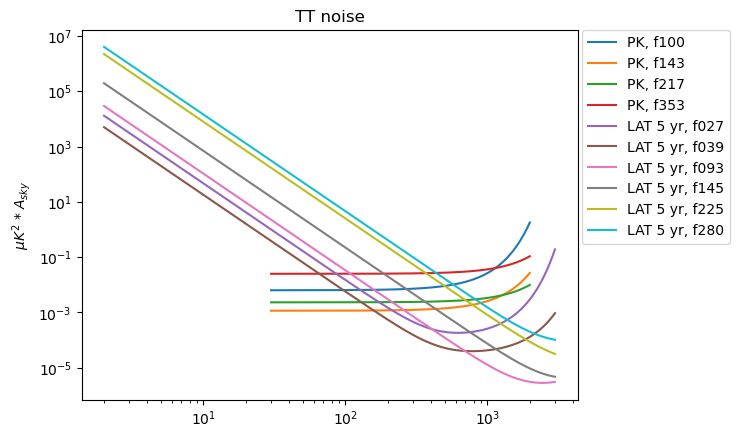

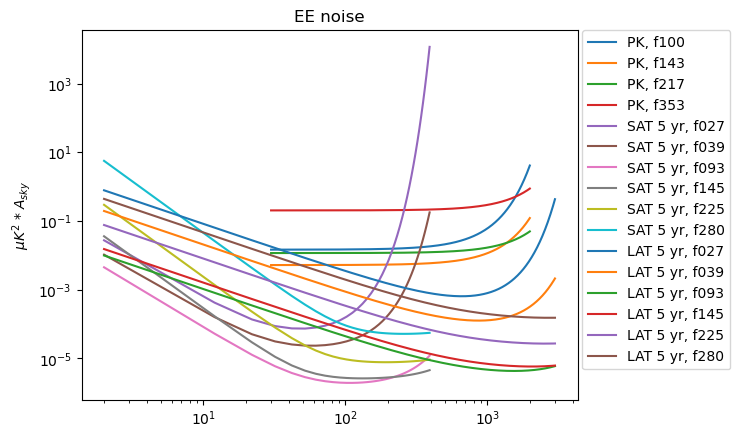

In [421]:
# N_ell plots for TT
dict_temp = full_noise_dict['PK']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'PK, {text}'.format(text = key))
    plt.ylabel(r'$\mu K^2$ * $A_{sky}$')

dict_temp = full_noise_dict['LAT']['LAT_y5_sm1']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'LAT 5 yr, {text}'.format(text = key))
    plt.title('TT noise')
    plt.ylabel(r'$\mu K^2$ * $A_{sky}$')

plt.loglog()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.show()

# N_ell plots for EE

dict_temp = full_noise_dict['PK_pol']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'PK, {text}'.format(text = key))

dict_temp = full_noise_dict['SAT']['SAT_y5_sm1fm0']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'SAT 5 yr, {text}'.format(text = key))

    
dict_temp = full_noise_dict['LAT_pol']['LAT_pol_y5_sm1']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'LAT 5 yr, {text}'.format(text = key))
    plt.title('EE noise')
    plt.ylabel(r'$\mu K^2$ * $A_{sky}$')

plt.loglog()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)


ok, so the way I think this is going to go is that I will save one big dict with ALL the dichroic combinations, and for each point in your 'data' dict, you save the noise spectrum and the theory spectrum that you are using (projected on the same ell_range), and from this one you take and build your singular power spectra

In [422]:
#req_spec is a dict that tells you first what experiments you will want in your likelihood, and for each what spectra and what frequencies.
#in the way this is currently set up (which can be subject to change), your full_noise_dict is what sets the tone for the cuts, the binning, etc
req_spec = {}
req_spec['SAT'] = SAT_pairs_all
req_spec['LAT'] = LAT_pairs_all
req_spec['LAT_pol'] = LAT_pairs_all
req_spec['LAT_cross'] = LAT_pairs_all
req_spec['PK'] = PK_pairs_all
req_spec['PK_pol'] = PK_pairs_all
req_spec['PK_cross'] = PK_pairs_all


# to create one likelihood, I request the experimental setup from the beginning; so, I need to specify the year that I want, fm,sm, and find that noise;
#it is only required for the SO params, and usually you will want a singular setup, although this is the only thing that makes the mixed likelihoods 
#different from one another

setup = { 'SAT':
    {'yrs' : 5,
        'sens_mode' : 1,
        'f_mode' : 0},
    'LAT':{
        'yrs' : 5,
        'sens_mode' : 1,
    },
          
}

so actually, there is no harm in reusing the full_lik_data mentality, since that is what you will be using to create the combined noise as well. I just think I want to modify the algorithm so that it stores the C_ell and the Noise separately.

In [423]:
def build_full_lik_data(req_spec, setup, full_noise_dict, cmb_theo_dict):
    '''req_spec is a dict that tells you first what experiments you will want in your likelihood,
    and for each what spectra and what frequencies.
    in the way this is currently set up (which can be subject to change),
    your full_noise_dict is what sets the tone for the cuts, the binning, etc.'''

    from iso_theory import _apply_cuts, _interp_to, make_cross_noise
    full_lik_data = {'metadata':{}, 
                    'data':{},
                    }
    #input the power spectra that you desire:
    for exp_key in req_spec:
        check_cross = False
        if exp_key in setup.keys():
            setup_exp = setup[exp_key]
        
        if exp_key == 'SAT':
            case_key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'
        elif exp_key == 'LAT' :
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['TT']
            cell_type = 'TT'

        elif exp_key == 'LAT_pol' :
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'

        elif exp_key == 'LAT_cross':
            check_cross = True
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['TE']
            cell_type = 'TE'
          
        elif exp_key == 'PK' :
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['TT']
            cell_type = 'TT'

        
        elif exp_key == 'PK_pol' :
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'

            
        elif exp_key == 'PK_cross':
            check_cross = True
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['TE']
            cell_type = 'TE'

        pairs_current = req_spec[exp_key]
        if not check_cross:
            #for PK et.al:
            if case_key  in full_noise_dict.keys():
                nz_dict = deepcopy(full_noise_dict[case_key]['nz_dict'])
                meta = deepcopy(full_noise_dict[case_key])
            # for SO
            elif case_key  in full_noise_dict[exp_key].keys():
                nz_dict = deepcopy(full_noise_dict[exp_key][case_key]['nz_dict'])
                meta = deepcopy(full_noise_dict[exp_key][case_key])
            else:
                raise KeyError("nu exista in dict")
        ### note: this is a way of handling TE noise (i.e. we are considering no TE noise, which is not accurate at all but what can I do)
        else:
            nz_dict = {}

        full_lik_data['metadata'][exp_key] = deepcopy(meta)
        full_lik_data['metadata'][exp_key].pop('nz_dict')
        full_lik_data['metadata'][exp_key].pop('ell_nz')
        full_lik_data['metadata'][exp_key]['cell_type'] = cell_type
        full_lik_data['data'][exp_key] = {}
        for spec_key in pairs_current:
            left, right = spec_key.split('x')
            f1 = left.split('_')[-1]
            f2 = right.split('_')[-1]
            
            ell_new = meta['ell_nz']
            ell_old = cmb_theo_dict['ell']
            cuts = meta['cuts']
            ell_old_cut, cell_cmb_cut = _apply_cuts(c_ell_theo, cmb_theo_dict['ell'], cuts)
            cell_cmb_cut = _interp_to(ell_new, ell_old_cut,cell_cmb_cut)
            ell_new_cut, cell_cmb_cut = _apply_cuts(cell_cmb_cut, ell_new, cuts)
            if not check_cross:
                if f1 == f2:
                    nz_arr = nz_dict['f{}'.format(f1)]
                    _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
                else:
                    nz_arr = make_cross_noise(nz_dict['f{}'.format(f1)],nz_dict['f{}'.format(f2)])
                    _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
            else:
                nz_arr_cut = cell_cmb_cut*0
            full_lik_data['data'][exp_key][spec_key] = {'c_ell' : cell_cmb_cut, 'n_ell': nz_arr_cut,'ell': ell_new_cut}

    return full_lik_data


In [424]:
so_mock_y5 = build_full_lik_data(req_spec, setup, full_noise_dict, cmb_theo_dict)

In [426]:
def print_keys(data, indent=0):
    for key, value in data.items():
        # Print the key with indentation for visual hierarchy
        print("  " * indent + str(key))
        
        # If the value is a nested dictionary, recurse
        if isinstance(value, dict):
            print_keys(value, indent + 1)

print_keys(lite_data)

TT
  c_ell
  cov
  ell
  dell
TE
  c_ell
  cov
  ell
  dell
EE
  c_ell
  cov
  ell
  dell


In [428]:
exp_types = {'TT': ['PK','LAT'],
            'TE':['PK_cross','LAT_cross'],
             'EE':['PK_pol','LAT_pol','SAT'],
            }

def extract_ell_scheme(data):
    return {
        pol: {
            'ell':  data[pol]['ell'],
            'dell': data[pol]['dell'],
        }
        for pol in ('TT', 'TE', 'EE')
    }

ell_scheme = extract_ell_scheme(lite_data)

In [478]:
def add_lite_to_out(out,lite_data):
    lite_corresp = {'PK_lite':'TT',
                    'PK_lite_pol':'EE',
                    'PK_lite_cross':'TE'
                   }
    for key in lite_corresp.keys():
        out['metadata'][key] = {
            'fsky' : 1.0
        }
        
        out['data'][key] = {
                    'c_ell': lite_data[lite_corresp[key]]['c_ell'],
                    'n_ell': lite_data[lite_corresp[key]]['c_ell']*0,
                    'cov':   lite_data[lite_corresp[key]]['cov'],
                    'ell':lite_data[lite_corresp[key]]['ell'],
                    'dell': lite_data[lite_corresp[key]]['dell'],
                }
    return out
def _build_ell_grid(ell_data, ell_scheme, ell_scheme_high_ref=None):
    lmin_data  = ell_data.min()
    lmax_data  = ell_data.max()
    lmin_schem = ell_scheme.min()
    lmax_schem = ell_scheme.max()

    dell_low  = ell_scheme[1] - ell_scheme[0]

    if lmin_data < lmin_schem:
        low_ext = np.arange(lmin_schem - dell_low, lmin_data - 1, -dell_low)[::-1]
    else:
        low_ext = np.array([])

    mid = ell_scheme[(ell_scheme >= lmin_data) & (ell_scheme <= lmax_data)]

    if lmax_data > lmax_schem:
        if ell_scheme_high_ref is not None:
            # follow the TT scheme where it covers, then use its last dell beyond
            dell_high   = ell_scheme_high_ref[-1] - ell_scheme_high_ref[-2]
            lmax_ref    = ell_scheme_high_ref.max()
            # bins from TT scheme that are beyond our scheme but within TT's range
            ref_ext     = ell_scheme_high_ref[(ell_scheme_high_ref > lmax_schem) &
                                              (ell_scheme_high_ref <= lmax_data)]
            # bins beyond TT's range, using TT's last dell
            if lmax_data > lmax_ref:
                far_ext = np.arange(lmax_ref + dell_high, lmax_data + 1, dell_high)
            else:
                far_ext = np.array([])
            high_ext = np.concatenate([ref_ext, far_ext])
        else:
            dell_high = ell_scheme[-1] - ell_scheme[-2]
            high_ext  = np.arange(lmax_schem + dell_high, lmax_data + 1, dell_high)
    else:
        high_ext = np.array([])

    return np.concatenate([low_ext, mid, high_ext])


def make_unified_noise(full_lik_data, ell_scheme, add_lite=False, lite_data=None):
    '''
    this function takes in a dict like full_lik_data and a universal ell scheme (bin centers + bin sizes) for TT, TE, EE
    returns dict with the same metadata, and same data keys, but you will have ONE c_ell for every experiment
    (it is the same for the same exp_key) and ONE noise spectrum (determined from inverse variance weighting)
    if the spectrum you project has data outside the ell_ranges dictated by cuts, take the first/last bin size
    and extend that to bin your spectrum all the way, but the ell_min and ell_max are dictated by the data
    '''
    # mapping from TE instrument to its TT and EE counterparts
    _cross_to_auto = {
        'PK_cross':  ('PK',  'PK_pol'),
        'LAT_cross': ('LAT', 'LAT_pol'),
    }
    exp_types = {
        'TT': ['PK', 'LAT'],
        'EE': ['PK_pol', 'LAT_pol', 'SAT'],
        'TE': ['PK_cross', 'LAT_cross'],   # TE last — needs TT and EE already done
    }
    out = {
        'metadata': full_lik_data['metadata'],
        'data': {}
    }

    # TE and EE use TT's scheme as the high-end reference so bin centers align
    ell_tt_scheme = ell_scheme['TT']['ell']

    for pol, instruments in exp_types.items():
        ell_schem  = ell_scheme[pol]['ell']
        dell_schem = ell_scheme[pol]['dell']

        for inst in instruments:
            cross_spectra = full_lik_data['data'][inst]

            # all cross-spectra share the same ell grid — take from first
            first    = next(iter(cross_spectra.values()))
            ell_data = first['ell']

            # build the output ell grid respecting data range + scheme binning
            # TE and EE follow TT's high-end binning pattern to ensure alignment
            if pol in ('TE', 'EE'):
                ell_out = _build_ell_grid(ell_data, ell_schem,
                                          ell_scheme_high_ref=ell_tt_scheme)
            else:
                ell_out = _build_ell_grid(ell_data, ell_schem)

            # bin widths on the output grid (constant extrapolation at boundaries)
            dell_out = _interp_to(ell_out, ell_schem, dell_schem)

            # fsky from metadata
            fsky = full_lik_data['metadata'][inst]['fsky']

            # c_ell: same for all cross-spectra within the instrument
            c_ell_out = _interp_to(ell_out, ell_data, first['c_ell'])

            # n_ell: inverse-variance weighting to one unified noise spectrum
            inv_noise_sum = np.zeros(len(ell_out))
            for arrays in cross_spectra.values():
                n_ell = arrays['n_ell']
                if n_ell.any() == 0:
                    continue
                else:
                    inv_noise_sum += 1.0 / _interp_to(ell_out, arrays['ell'], n_ell)
            n_ell_out = (1.0 / inv_noise_sum if inv_noise_sum.all() != 0 else c_ell_out * 0)

            # covariance: Knox covariance under Gaussian assumption with C+N as total power
            if pol in ('TT', 'EE'):
                total   = c_ell_out + n_ell_out
                cov_out = knox_auto_cov(total, ell_out, dell_out, fsky)
            else:
                # TE cross-spectrum: look up already-computed TT and EE total spectra
                tt_key, ee_key = _cross_to_auto[inst]
                tt = out['data'][tt_key]
                ee = out['data'][ee_key]
                c_tt_n  = _interp_to(ell_out, tt['ell'], tt['c_ell'] + tt['n_ell'])
                c_ee_n  = _interp_to(ell_out, ee['ell'], ee['c_ell'] + ee['n_ell'])
                cov_out = knox_cross_cov(c_ell_out, c_tt_n, c_ee_n,
                                         ell_out, dell_out, fsky)

            out['data'][inst] = {
                'c_ell': c_ell_out,
                'n_ell': n_ell_out,
                'cov':   cov_out,
                'ell':   ell_out,
                'dell':  dell_out,
            }

    if add_lite:
        if lite_data is None:
            raise ValueError("please provide the lite dict, silly!")
        out = add_lite_to_out(out, lite_data)

    return out


In [479]:
#so_lik_unif = make_unified_noise(so_mock_y5 ,ell_scheme)
so_lik_unif = make_unified_noise(so_mock_y5 ,ell_scheme, add_lite = True,lite_data = lite_data)

In [480]:
so_lik_unif['metadata']

{'SAT': {'yrs': 5.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 400,
  'dell': 10,
  'cuts': [30, 400],
  'cell_type': 'EE'},
 'LAT': {'yrs': 5.0,
  'sens_mode': 1,
  'fsky': 0.1,
  'lmax': 3000,
  'dell': 10,
  'cuts': [400, 3000],
  'cell_type': 'TT'},
 'LAT_pol': {'yrs': 5.0,
  'sens_mode': 1,
  'fsky': 0.1,
  'lmax': 3000,
  'dell': 10,
  'cuts': [400, 3000],
  'cell_type': 'EE'},
 'LAT_cross': {'yrs': 5.0,
  'sens_mode': 1,
  'fsky': 0.1,
  'lmax': 3000,
  'dell': 10,
  'cuts': [400, 3000],
  'cell_type': 'TE'},
 'PK': {'lmax': 2000,
  'dell': 10,
  'fsky': 1.0,
  'cuts': [30, 2000],
  'cell_type': 'TT'},
 'PK_pol': {'lmax': 2000,
  'dell': 10,
  'fsky': 1.0,
  'cuts': [30, 2000],
  'cell_type': 'EE'},
 'PK_cross': {'lmax': 2000,
  'dell': 10,
  'fsky': 1.0,
  'cuts': [30, 2000],
  'cell_type': 'TE'},
 'PK_lite': {'fsky': 1.0},
 'PK_lite_pol': {'fsky': 1.0},
 'PK_lite_cross': {'fsky': 1.0}}

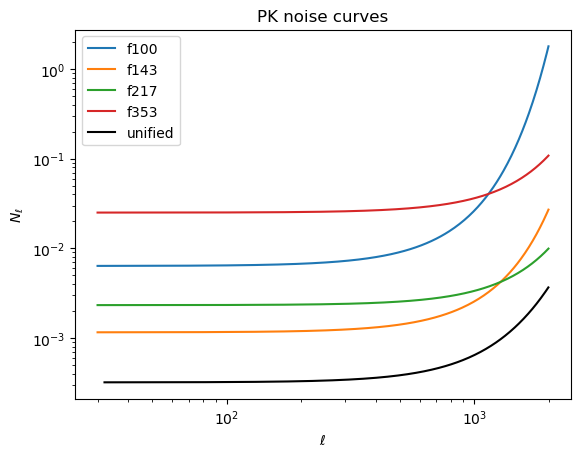

In [481]:
def plot_noise_curves_pk(exp_temp = 'PK'):
    dict_temp = full_noise_dict[exp_temp]['nz_dict']
    for key in dict_temp.keys():
        plt.plot(full_noise_dict[exp_temp]['ell_nz'], dict_temp[key], label = key)
        plt.loglog()
    plt.plot(so_lik_unif['data'][exp_temp]['ell'],so_lik_unif['data'][exp_temp]['n_ell'], color = 'black', label = 'unified')
    plt.title('{} noise curves'.format(exp_temp))
    plt.ylabel(r'$N_\ell$')
    plt.xlabel(r'$\ell$')
    plt.legend()
    plt.show()

plot_noise_curves_pk()

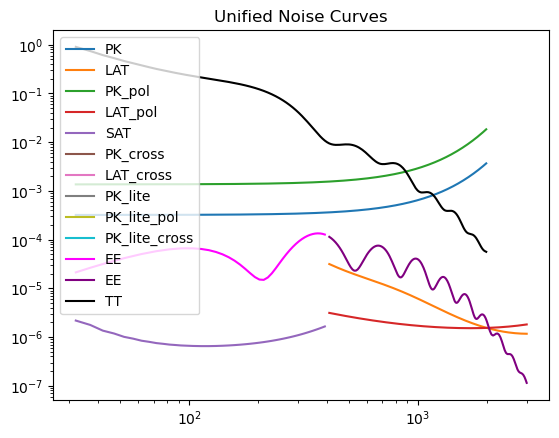

In [482]:
dict_temp = so_lik_unif['data']
for exp in dict_temp.keys():
    if isinstance(dict_temp[exp]['n_ell'],int) == False:
        plt.plot(dict_temp[exp]['ell'],dict_temp[exp]['n_ell'], label = exp )
plt.plot(so_lik_unif['data']['SAT']['ell'],so_lik_unif['data']['SAT']['c_ell'], label = 'EE',color = 'magenta')
plt.plot(so_lik_unif['data']['LAT_pol']['ell'],so_lik_unif['data']['LAT_pol']['c_ell'], label = 'EE',  color = 'purple')
plt.plot(so_lik_unif['data']['PK']['ell'],so_lik_unif['data']['PK']['c_ell'], label = 'TT',color = 'black')

plt.loglog()
plt.title('Unified Noise Curves')
plt.legend()

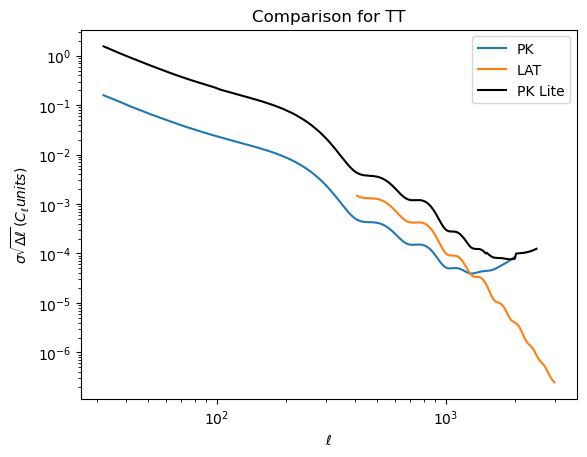

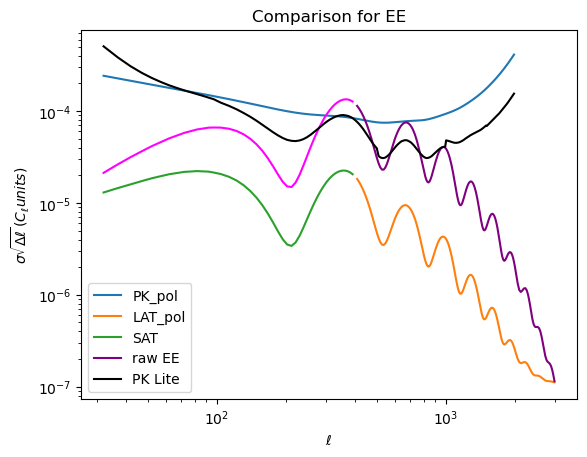

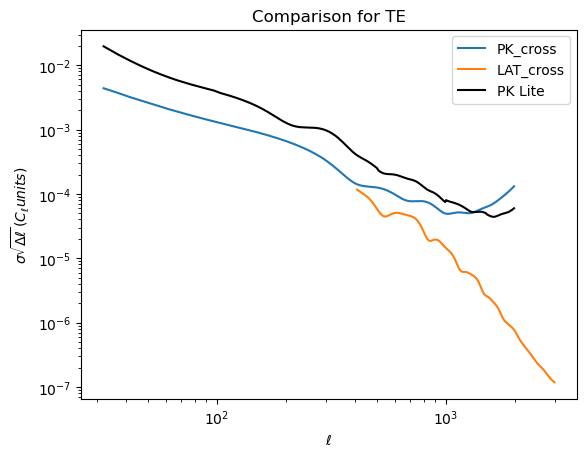

In [483]:
def raw_EE_func(so_lik_unif, pref = False):
        if pref:
            fac = np.sqrt(1/(2*so_lik_unif['data']['SAT']['ell']+1))
        else:
            fac = 1
        plt.plot(so_lik_unif['data']['SAT']['ell'],fac *so_lik_unif['data']['SAT']['c_ell'], color = 'magenta')
        if pref:
            fac = np.sqrt(1/(2*so_lik_unif['data']['LAT_pol']['ell']+1))
        else:
            fac = 1        

        plt.plot(so_lik_unif['data']['LAT_pol']['ell'],fac * so_lik_unif['data']['LAT_pol']['c_ell'], label = 'raw EE', color = 'purple')
    

def plot_cov(exp_temp_arr, cell_type, lite_data = lite_data ,pref = False, raw_EE = False):
    for exp_temp in exp_temp_arr:
        dict_temp = so_lik_unif['data'][exp_temp]
        ell_plot = dict_temp['ell']
        err = np.sqrt(dict_temp['cov'] * dict_temp['dell'])
        err_lite = np.sqrt(lite_data[cell_type]['cov'] * lite_data[cell_type]['dell'])
        ell_lite = lite_data[cell_type]['ell']
        if pref:
            err *= (ell_plot*(ell_plot+1)/2/np.pi)
            err_lite *= (ell_lite*(ell_lite+1)/2/np.pi)
        plt.plot(ell_plot, err, label = exp_temp)

    if raw_EE:
        raw_EE_func(so_lik_unif)
    if pref:
        ylabel = r"$\sigma \sqrt{\Delta \ell} \, (D_{\ell} units)$"
    else:
        ylabel = r'$\sigma \sqrt{\Delta \ell} \, (C_{\ell} units)$'
    plt.plot(ell_lite,err_lite, label = 'PK Lite', color = 'black')
    plt.ylabel(ylabel)
    plt.xlabel(r'$\ell$')
    plt.title('Comparison for {}'.format(cell_type))
    plt.loglog()
    plt.legend()
    plt.show()

plot_cov(['PK','LAT'],'TT')
plot_cov(['PK_pol','LAT_pol','SAT'],'EE', raw_EE = True)
plot_cov(['PK_cross','LAT_cross'],'TE')

### making the final versison of the Covariance matrix using all of my datasets;
    - should I do SAT + LAT??
    - does ACT come in at any point??=> I should ask Jo.

In [484]:
def make_best_per_bin(so_lik_unif, ell_scheme, add_lite=True):
    '''
    For each polarization type (TT, EE, TE), selects at each ell bin the
    experiment with the smallest sigma * sqrt(dell). The ell grid is built
    in two parts:
      - within the PK Lite range: use the scheme bin centers directly,
        guaranteeing alignment across all polarization types
      - beyond the PK Lite range: take the intersection of whatever
        experiments extend that far, per polarization type, then intersect
        across TT/TE/EE at the end
    Returns a dict with keys 'TT', 'TE', 'EE'.
    '''
    if add_lite:
        exp_types = {
            'TT': ['PK', 'LAT', 'PK_lite'],
            'EE': ['PK_pol', 'LAT_pol', 'SAT', 'PK_lite_pol'],
            'TE': ['PK_cross', 'LAT_cross', 'PK_lite_cross'],
        }
    else:
        exp_types = {
            'TT': ['PK', 'LAT'],
            'EE': ['PK_pol', 'LAT_pol', 'SAT'],
            'TE': ['PK_cross', 'LAT_cross'],
        }

    # reference ell grid from PK Lite scheme (same for TT, TE, EE)
    ell_lite_ref = ell_scheme['TT']['ell']  # all three share the same scheme
    lmax_lite    = ell_lite_ref.max()

    out = {'metadata':deepcopy(so_lik_unif['metadata']),
           'data': {} 
          }

    for cell_type, instruments in exp_types.items():

        available = [inst for inst in instruments if inst in so_lik_unif['data']]

        # within PK Lite range: use scheme bin centers directly
        ell_in_range = ell_lite_ref.copy()

        # beyond PK Lite range: take union of experiments that extend there,
        # intersected later across polarization types by harmonize_ell_grids
        all_ells_ext = np.concatenate(
            [so_lik_unif['data'][inst]['ell'][so_lik_unif['data'][inst]['ell'] > lmax_lite]
             for inst in available]
        )
        ell_ext = np.unique(all_ells_ext) if len(all_ells_ext) > 0 else np.array([])

        ell_global = np.concatenate([ell_in_range, ell_ext])

        c_ell_best  = np.full(len(ell_global), np.nan)
        n_ell_best  = np.full(len(ell_global), np.nan)
        cov_best    = np.full(len(ell_global), np.nan)
        dell_best   = np.full(len(ell_global), np.nan)
        sigma_best  = np.full(len(ell_global), np.inf)
        source_best = np.full(len(ell_global), '', dtype=object)

        for inst in available:
            d     = so_lik_unif['data'][inst]
            ell_i = d['ell']
            sigma = np.sqrt(d['cov'] * d['dell'])

            for k, ell_val in enumerate(ell_global):
                idx = np.where(ell_i == ell_val)[0]
                if len(idx) == 0:
                    continue
                idx = idx[0]
                if sigma[idx] < sigma_best[k]:
                    sigma_best[k]  = sigma[idx]
                    c_ell_best[k]  = d['c_ell'][idx]
                    n_ell_best[k]  = d['n_ell'][idx]
                    cov_best[k]    = d['cov'][idx]
                    dell_best[k]   = d['dell'][idx]
                    source_best[k] = inst

        mask = ~np.isnan(c_ell_best)
        out['data'][cell_type] = {
            'c_ell':  c_ell_best[mask],
            'n_ell':  n_ell_best[mask],
            'cov':    cov_best[mask],
            'dell':   dell_best[mask],
            'ell':    ell_global[mask],
            'source': source_best[mask],
        }

    return out

In [485]:
so_lik_best = make_best_per_bin(so_lik_unif, ell_scheme)

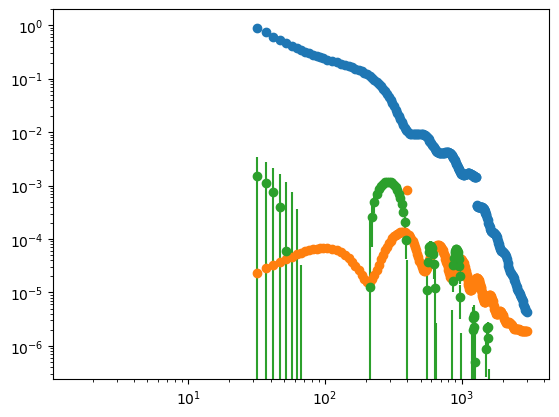

In [486]:
for key in so_lik_best['data'].keys():
    plt.errorbar(so_lik_best['data'][key]['ell'],so_lik_best['data'][key]['c_ell'] + so_lik_best['data'][key]['n_ell'], yerr =  np.sqrt(so_lik_best['data'][key]['cov']), marker = 'o',linestyle = 'None')
    #print(so_lik_best[key]['source'])
    plt.loglog()


In [487]:
def make_ttteee_cov(so_lik_best):
    '''
    Builds a block-diagonal TTTEEE covariance matrix of shape (3N, 3N) where
    N is the number of ell bins. Each of the 9 blocks is diagonal, filled
    according to the Gaussian (Knox) covariance formula.

    Block ordering: [TT | TE | EE]

    fsky is extracted per bin from the metadata using the source array.
    '''
    metadata = so_lik_best['metadata']
    tt = so_lik_best['data']['TT']
    te = so_lik_best['data']['TE']
    ee = so_lik_best['data']['EE']

    ell  = tt['ell']
    dell = tt['dell']

    # extract per-bin fsky directly from metadata using the source array
    fsky_tt = np.array([metadata[src]['fsky'] for src in tt['source']])
    fsky_te = np.array([metadata[src]['fsky'] for src in te['source']])
    fsky_ee = np.array([metadata[src]['fsky'] for src in ee['source']])

    # use the most conservative fsky at each bin across all three
    fsky = np.minimum(fsky_tt, np.minimum(fsky_te, fsky_ee))

    # total spectra
    ctt = tt['c_ell'] + tt['n_ell']
    cee = ee['c_ell'] + ee['n_ell']
    cte = te['c_ell']   # TE has no noise bias

    prefactor_auto  = 2.0 / (2.0 * ell + 1.0) / dell / fsky
    prefactor_cross = 1.0 / (2.0 * ell + 1.0) / dell / fsky

    # ── diagonal of each block ────────────────────────────────────────────────
    cov_tt_tt = prefactor_auto  * ctt**2
    cov_ee_ee = prefactor_auto  * cee**2
    cov_te_te = prefactor_cross * (cte**2 + ctt * cee)
    cov_tt_ee = prefactor_auto  * cte**2
    cov_tt_te = prefactor_auto  * cte * ctt
    cov_ee_te = prefactor_auto  * cte * cee

    # ── assemble the 3N x 3N matrix ───────────────────────────────────────────
    N   = len(ell)
    cov = np.zeros((3 * N, 3 * N))

    idx_tt = slice(0,     N)
    idx_te = slice(N,   2*N)
    idx_ee = slice(2*N, 3*N)

    np.fill_diagonal(cov[idx_tt, idx_tt], cov_tt_tt)
    np.fill_diagonal(cov[idx_te, idx_te], cov_te_te)
    np.fill_diagonal(cov[idx_ee, idx_ee], cov_ee_ee)

    np.fill_diagonal(cov[idx_tt, idx_ee], cov_tt_ee)
    np.fill_diagonal(cov[idx_ee, idx_tt], cov_tt_ee)

    np.fill_diagonal(cov[idx_tt, idx_te], cov_tt_te)
    np.fill_diagonal(cov[idx_te, idx_tt], cov_tt_te)

    np.fill_diagonal(cov[idx_ee, idx_te], cov_ee_te)
    np.fill_diagonal(cov[idx_te, idx_ee], cov_ee_te)

    return cov

In [488]:
ttteee_cov = make_ttteee_cov(so_lik_best)

### 3. Fisher Forecasting

In [489]:
from fisher import (
    SpectrumBand,
    FisherResult,
    fisher_forecast,
    compute_dC_bands,
    _step_for,
    _perturb,
    parse_spectrum_bands,
    eval_cls_on_bands,
    plot_save_suite,
)

def parse_bands_from_best(so_lik_best):
    '''
    Parse so_lik_best into a flat list of SpectrumBand objects for use with
    fisher_forecast. Creates one band per polarization type (TT, TE, EE),
    using the already-computed diagonal covariance from make_best_per_bin.

    The cov stored in so_lik_best already encodes Var(C_hat_ell) with fsky,
    so no further weighting is needed in fisher_forecast.
    '''
    metadata = so_lik_best['metadata']
    bands    = []

    for cell_type in ('TT', 'TE', 'EE'):
        d = so_lik_best['data'][cell_type]

        # use the most conservative fsky across the bins as a scalar summary
        fsky = min(metadata[src]['fsky'] for src in np.unique(d['source']))

        bands.append(SpectrumBand(
            exp_key   = f'best_{cell_type}',
            channel   = f'best_{cell_type}',
            cell_type = cell_type,
            ell       = d['ell'].astype(int),
            dell      = d['dell'],
            fsky      = fsky,
            cov       = d['cov'],
        ))

    return bands


def fisher_forecast_ttteee(
    theta0:        dict,
    param_list:    list,
    so_lik_best:   dict,
    compute_cls:   callable,
    steps:         dict,
    scaled_params: set  = frozenset(),
    ell_max:       int  = 10_000,
    use_pinv:      bool = False,
) -> FisherResult:
    '''
    Fisher forecast using the full TTTEEE covariance matrix (with off-diagonal
    TT-TE, TT-EE, EE-TE blocks), computed via make_ttteee_cov.

    At each ell bin b, the 3-vector dC_α(b) = [dC_TT/dθ_α, dC_TE/dθ_α, dC_EE/dθ_α]
    is formed, and the contribution to F_αβ is:

        dC_α(b)^T · C_3x3^{-1}(b) · dC_β(b)

    where C_3x3(b) is the 3x3 covariance block at bin b from make_ttteee_cov.

    Parameters
    ----------
    theta0       : fiducial parameter dict
    param_list   : parameters to forecast
    so_lik_best  : output of make_best_per_bin (with metadata)
    compute_cls  : callable(**theta, lmax=int) -> {cell_type: Cl_array}
    steps        : step sizes keyed by param name
    scaled_params: params multiplied by 1e10 before differencing
    ell_max      : passed to compute_cls
    use_pinv     : use pseudo-inverse when inverting F
    '''
    # ── build full TTTEEE covariance and extract per-bin 3x3 blocks ──────────
    cov_full = make_ttteee_cov(so_lik_best)   # shape (3N, 3N)
    N        = len(so_lik_best['data']['TT']['ell'])

    # invert each 3x3 block independently — covariance is block-diagonal in ell
    cov_inv_blocks = np.zeros((N, 3, 3))
    for b in range(N):
        block = cov_full[np.ix_([b, b+N, b+2*N], [b, b+N, b+2*N])]
        cov_inv_blocks[b] = np.linalg.inv(block)

    # ell grids (all three are identical after harmonization)
    ell_tt = so_lik_best['data']['TT']['ell'].astype(int)

    # ── compute derivatives for all parameters ────────────────────────────────
    dC = []
    for param in param_list:
        step, _ = _step_for(param, steps, scaled_params)

        theta_hi = _perturb(theta0, param, +step, scaled_params)
        theta_lo = _perturb(theta0, param, -step, scaled_params)

        cls_hi = compute_cls(**theta_hi, lmax=ell_max)
        cls_lo = compute_cls(**theta_lo, lmax=ell_max)

        # derivative vectors per bin: [dTT, dTE, dEE]
        dC_tt = (np.asarray(cls_hi['TT'])[ell_tt] - np.asarray(cls_lo['TT'])[ell_tt]) / (2*step)
        dC_te = (np.asarray(cls_hi['TE'])[ell_tt] - np.asarray(cls_lo['TE'])[ell_tt]) / (2*step)
        dC_ee = (np.asarray(cls_hi['EE'])[ell_tt] - np.asarray(cls_lo['EE'])[ell_tt]) / (2*step)

        dC.append(np.stack([dC_tt, dC_te, dC_ee], axis=1))  # shape (N, 3)

    # ── Fisher matrix ─────────────────────────────────────────────────────────
    npar = len(param_list)
    F    = np.zeros((npar, npar))

    for i in range(npar):
        for j in range(i, npar):
            # sum over ell bins: dC_i^T C^{-1} dC_j
            s = sum(
                dC[i][b] @ cov_inv_blocks[b] @ dC[j][b]
                for b in range(N)
            )
            F[i, j] = s
            F[j, i] = s

    # ── parameter covariance ──────────────────────────────────────────────────
    inv        = np.linalg.pinv if use_pinv else np.linalg.inv
    Cov_params = inv(F)
    sigma      = np.sqrt(np.diag(Cov_params))

    # package bands for compatibility with FisherResult
    bands = parse_bands_from_best(so_lik_best)

    return FisherResult(
        F          = F,
        Cov_params = Cov_params,
        sigma      = sigma,
        dC         = dC,
        bands      = bands,
        param_list = list(param_list),
    )

array([[5.02932169e-02, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.93867241e-02, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.76692885e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.89219438e-16, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 3.82981831e-16, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 3.76933706e-16]], shape=(690, 690))